In [34]:
import numpy as np
import matplotlib.pyplot as plt
from mnist import load_mnist_ubyte
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

In [35]:
(x_train, y_train), (x_test, y_test) = load_mnist_ubyte()
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 784) (60000,)
(10000, 784) (10000,)


In [36]:
class MLP(nn.Module):
    def __init__(self, H=2):
        super().__init__()
        self.input_layer = nn.Linear(784, 128)
        layers = []
        for _ in range(0, H):
            layers.append(nn.Linear(128, 128))
        self.hidden_layers = nn.ModuleList(layers)
        self.output_layer = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.input_layer(x))
        for layer in self.hidden_layers:
            x = F.relu(layer(x))
        return self.output_layer(x)

In [37]:
model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [ ]:
def train(model, criterion, optimizer, x_train, y_train, x_test, y_test, epochs=10, batch_size=128):
    for epoch in range(epochs):
        for i in tqdm(range(0, len(x_train), batch_size)):
            x_batch = x_train[i : i + batch_size]
            y_batch = y_train[i : i + batch_size]
            model.train()
            optimizer.zero_grad()
            output = model(x_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()

            model.eval()
            with torch.no_grad():
                test_output = model(x_test)
                test_loss = criterion(test_output, y_test)
                pred = test_output.argmax(dim=1)
                accuracy = (pred == y_test).float().mean().item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}, Accuracy: {accuracy:.4f}")

In [39]:
def predicted_details(res):
    for prob in res:
        print(f"{np.where(res == prob)[0][0]}: {prob*100:.2f}%")

In [40]:
softmax = nn.Softmax(dim=-1)

In [41]:
train(model, criterion, optimizer, x_train_tensor, y_train_tensor, x_test_tensor, y_test_tensor)

100%|██████████| 938/938 [00:24<00:00, 38.36it/s]


Epoch 1/10, Loss: 1.9024, Test Loss: 1.8552, Accuracy: 0.5742


100%|██████████| 938/938 [00:24<00:00, 37.59it/s]


Epoch 2/10, Loss: 0.4313, Test Loss: 0.5676, Accuracy: 0.8290


100%|██████████| 938/938 [00:27<00:00, 34.34it/s]


...

Epoch 8/10, Loss: 0.0894, Test Loss: 0.2399, Accuracy: 0.9305


100%|██████████| 938/938 [00:27<00:00, 34.22it/s]


Epoch 9/10, Loss: 0.0748, Test Loss: 0.2194, Accuracy: 0.9355


100%|██████████| 938/938 [00:28<00:00, 32.37it/s]

Epoch 10/10, Loss: 0.0633, Test Loss: 0.2005, Accuracy: 0.9411


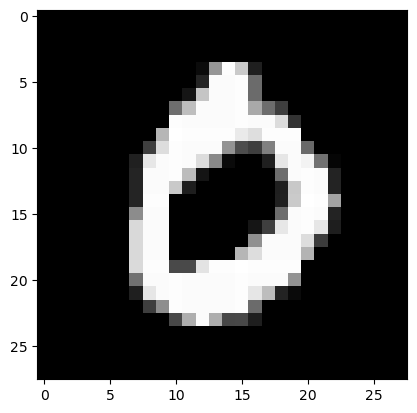

In [42]:
plt.imshow(x_test[3].reshape(28, 28), cmap="gray")

In [43]:
predicted_details(softmax(model.forward(x_test_tensor[3])))

0: 99.90%
1: 0.00%
2: 0.02%
3: 0.00%
4: 0.00%
5: 0.06%
6: 0.00%
7: 0.00%
8: 0.00%
9: 0.00%
